# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [4]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [5]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


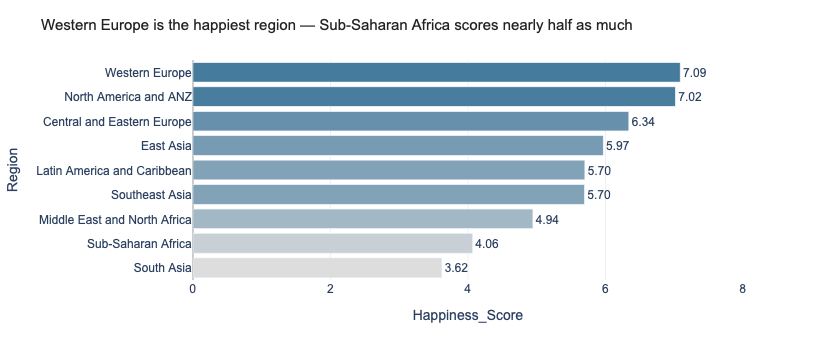

In [7]:
# Task 1: Regional comparison bar chart

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))

# Step 2: Build chart
fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text='Happiness_Score',
    color='Happiness_Score',
    color_continuous_scale=['#DDDDDD', '#457B9D']
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside',
)

fig.update_layout(
    title=dict(
        text="Western Europe is the happiest region — Sub-Saharan Africa scores nearly half as much",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        range=[0, 8],
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=True, zerolinecolor='#CCCCCC'
    ),
    yaxis=dict(showgrid=False, showline=False),
    coloraxis_showscale=False,
    margin=dict(r=80)
)

fig.show()

---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


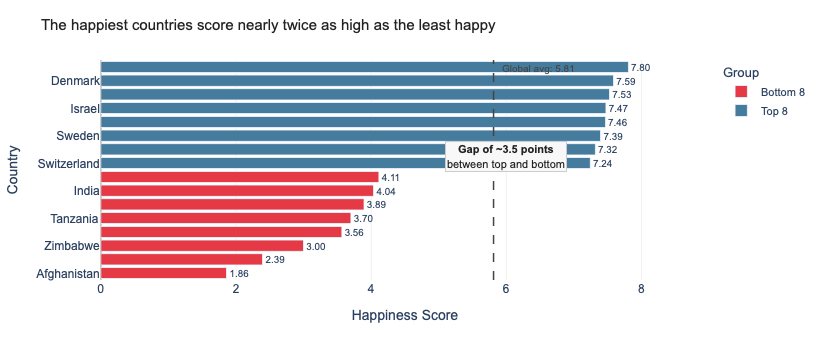

In [8]:
# Task 2: Top 8 vs. Bottom 8 contrast

top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()

COLOR_MAP = {'Top 8': '#457B9D', 'Bottom 8': '#E63946'}

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    color_discrete_map=COLOR_MAP,
    text='Happiness_Score'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Global average line
fig.add_vline(
    x=global_avg,
    line_dash='dash',
    line_color='#444444',
    line_width=1.5
)
fig.add_annotation(
    x=global_avg, y=1, yref='paper',
    text=f"Global avg: {global_avg:.2f}",
    showarrow=False, xanchor='left', xshift=6,
    font=dict(family='Arial', size=10, color='#444444')
)

# Gap annotation
fig.add_annotation(
    x=6, y=8.5,
    text="<b>Gap of ~3.5 points</b><br>between top and bottom",
    showarrow=False,
    font=dict(family='Arial', size=11, color='#222222'),
    bgcolor='#F8F8F8',
    bordercolor='#CCCCCC',
    borderwidth=1
)

fig.update_layout(
    title=dict(
        text="The happiest countries score nearly twice as high as the least happy",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        range=[0, 9],
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=True, zerolinecolor='#CCCCCC',
        title='Happiness Score'
    ),
    yaxis=dict(showgrid=False, showline=False),
    legend=dict(title='Group', font=dict(family='Arial', size=11)),
    margin=dict(r=80)
)

fig.show()

---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


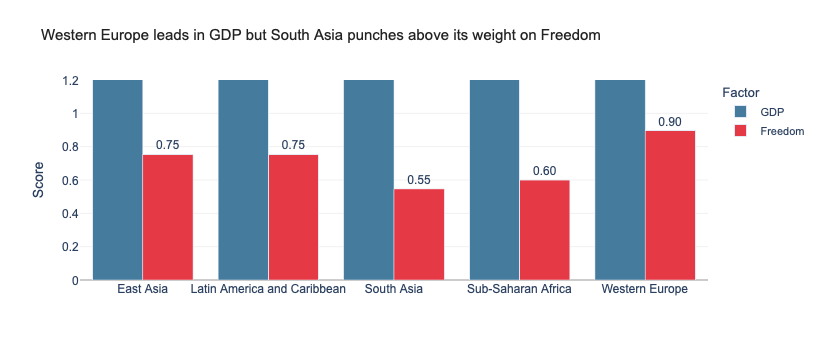

In [9]:
# Stretch goal — grouped bar chart: GDP vs Freedom across 5 regions

selected_regions = ['Western Europe', 'Latin America and Caribbean', 
                    'East Asia', 'Sub-Saharan Africa', 'South Asia']

region_factors = (
    df[df['Region'].isin(selected_regions)]
    .groupby('Region')[['GDP', 'Freedom']]
    .mean()
    .reset_index()
)

# Melt to long format for grouped bar
melted = region_factors.melt(
    id_vars='Region',
    value_vars=['GDP', 'Freedom'],
    var_name='Factor',
    value_name='Score'
)

COLOR_MAP = {
    'GDP':     '#457B9D',
    'Freedom': '#E63946'
}

fig = px.bar(
    melted,
    x='Region',
    y='Score',
    color='Factor',
    barmode='group',
    color_discrete_map=COLOR_MAP,
    text='Score'
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    title=dict(
        text="Western Europe leads in GDP but South Asia punches above its weight on Freedom",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        showgrid=False, showline=False,
        title=None
    ),
    yaxis=dict(
        range=[0, 1.2],
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=True, zerolinecolor='#CCCCCC',
        title='Score'
    ),
    legend=dict(title='Factor', font=dict(family='Arial', size=11)),
    margin=dict(t=80, b=80)
)

fig.show()

